# GasOpt — empirical optimization and chronological evaluation

This notebook develops the mathematics **before** displaying Python results.
It uses only verified local Dune extracts. Missing real data is shown explicitly;
data-dependent cells are skipped without substituting synthetic observations.
Prerequisites: Phase 1, notebook 02 and the offline preparation command.

## 1. Research question

How should a crypto treasury schedule delay-tolerant Ethereum transactions to
minimize expected costs while controlling exposure to extreme daily price paths?
We compare static plans selected on TRAIN and applied unchanged to later TEST days.

## 2. Empirical data

Training scenarios are complete UTC days with 12 two-hour slot medians from Dune
`gas.fees`, Ethereum only. Gas requirements come from observed training transaction
gas use. See notebook 02 for extraction provenance, the wei/gwei fee audit and
all retained/removed dates. No network is used here.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

from gasopt.config import load_config
from gasopt.data.empirical import build_workload, daily_scenarios, split_daily_slots
from gasopt.empirical_study import load_processed, fit_strategies, study_from_frames, run_study
from gasopt.baselines import immediate_schedule
from gasopt.evaluation.metrics import mean_prices_gwei, scenario_costs_eth, weighted_var_cvar
from gasopt.evaluation.out_of_sample import cost_summary, evaluate_schedules

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
config = load_config(ROOT / 'config/empirical.toml')
PROCESSED = ROOT / 'data/processed'
OUTPUT = ROOT / 'outputs/empirical'
DATA_LABEL = 'EMPIRICAL ETHEREUM'
DATA_AVAILABLE = (PROCESSED / 'metadata.json').exists()
if DATA_AVAILABLE:
    slots, observations, metadata = load_processed(PROCESSED, config)
    train_slots, test_slots = split_daily_slots(slots, config)
    display(Markdown('**Verified local empirical data loaded. All analysis below is offline.**'))
else:
    display(Markdown('**EMPIRICAL RESULTS PENDING.** No verified Dune extract is present. '
                     'Run the extraction/import and preparation steps in `docs/phase2.md`. '
                     'Data-dependent cells below are explicitly skipped; no synthetic substitute is used.'))
pd.set_option('display.float_format', lambda value: f'{value:.9f}')
display(pd.Series(config.to_dict(), name='Prespecified configuration').to_frame())

**Verified local empirical data loaded. All analysis below is offline.**

,Prespecified configuration
train_start,2025-01-01
train_end,2025-12-31
test_start,2026-01-01
test_end,2026-03-31
alpha,0.950000000
lambda_grid,"(0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2...."
min_train_tail_count,10.000000000
max_missing_day_fraction,0.050000000
transaction_count,30
sample_seed,20260923


In [2]:
if DATA_AVAILABLE:
    display(pd.Series(metadata['quality'], name='Empirical sample audit').to_frame())
    transactions, workload, construction = build_workload(observations, config)
    train = daily_scenarios(train_slots)
    test = daily_scenarios(test_slots)

,Empirical sample audit
raw_aggregate_rows,5460
raw_transaction_observations,724380678
valid_transaction_observations,724380678
excluded_transaction_observations,0
raw_date_min,2025-01-01
raw_date_max,2026-03-31
retained_aggregate_rows,5460
retained_daily_scenarios,455
timezone,UTC
duplicate_day_slots,0


## 3. Decision problem

A fixed daily treasury workload contains approximately 30 indivisible transactions.
Each is available at a release slot and must execute by a deadline. Gas requirements
are empirical; releases, deadlines and priority classes are business assumptions.
One schedule is selected before observing the day's trajectory. There is no recourse.

In [3]:
if DATA_AVAILABLE:
    display(workload[['transaction_id','gas_used','release_slot','deadline_slot','priority_class','timing_origin']])

,transaction_id,gas_used,release_slot,deadline_slot,priority_class,timing_origin
0,treasury_01,21000,1,2,URGENT,explicit business assumption
1,treasury_02,21000,1,4,STANDARD,explicit business assumption
2,treasury_03,296588,1,8,FLEXIBLE,explicit business assumption
3,treasury_04,46109,2,3,URGENT,explicit business assumption
4,treasury_05,51957,2,5,STANDARD,explicit business assumption
5,treasury_06,21000,2,9,FLEXIBLE,explicit business assumption
6,treasury_07,96383,3,4,URGENT,explicit business assumption
7,treasury_08,41309,3,6,STANDARD,explicit business assumption
8,treasury_09,221254,3,10,FLEXIBLE,explicit business assumption
9,treasury_10,21000,4,5,URGENT,explicit business assumption


## 4. Indices and parameters

| Symbol | Meaning | Units |
|:--|:--|:--|
| $i\in I$ | Fixed treasury transaction | Index |
| $t\in\{1,\ldots,12\}$ | UTC two-hour slot | Index |
| $s\in S_{train}$ | Historical TRAIN day | Index |
| $g_i$ | Observed training gas usage | gas |
| $r_i,d_i$ | Business release and deadline | Slot indices |
| $p_{ts}$ | Within-slot observed median price | gwei/gas |
| $q_s=1/S$ | Empirical scenario probability | Dimensionless |
| $\alpha$ | CVaR confidence level | Dimensionless |
| $\lambda\ge0$ | Prespecified risk weight | Dimensionless |

## 5. Decision variables

$$x_{it}=\begin{cases}1&\text{transaction }i\text{ executes in slot }t,\\0&\text{otherwise.}\end{cases}$$

No scenario index appears on $x$: the schedule cannot see the realized path.
CVaR uses an unrestricted threshold $\eta\in\mathbb R$ and nonnegative excesses
$\xi_s\ge0$, both in ETH.

## 6. Constraints

Define $A=\{(i,t):r_i\le t\le d_i\}$ and impose

$$\sum_{t=r_i}^{d_i}x_{it}=1\quad\forall i,\qquad
x_{it}\in\{0,1\}\quad((i,t)\in A),\qquad x_{it}=0\quad((i,t)\notin A).$$

These prevent omission, duplication, execution before release and missed deadlines.
Optional $\sum_i x_{it}\le K_t$ constrains transaction counts; it is disabled in
this empirical experiment. It is not Ethereum block gas capacity.

## 7. Scenario cost

$$C_s(x)=10^{-9}\sum_{(i,t)\in A}g_i p_{ts}x_{it}\quad\text{ETH}.$$

The unit calculation is gas × gwei/gas × ETH/gwei. The observed execution price
is an all-in proxy including base and priority fees, not base fee alone. We do
not include blob fees or convert costs to USD.

## 8. Expected cost

$$E_{train}[C(x)]=\frac1S\sum_{s\in S_{train}}C_s(x).$$

The deterministic mean vector is $\bar p_t=\frac1S\sum_s p_{ts}$: a mean of daily
slot medians, not the transaction-level mean gas-price column in the raw extract.

## 9. CVaR

$$\operatorname{CVaR}_{\alpha}(C)=\min_{\eta\in\mathbb R}
\left[\eta+\frac{1}{(1-\alpha)S}\sum_s(C_s-\eta)_+\right].$$

The default empirical $\alpha=.95$ is allowed only with the configured minimum
TRAIN tail mass. Report $(1-\alpha)S$ explicitly; 365 days give 18.25 equivalents.
CVaR includes fractional mass at a discrete quantile boundary. It is not generally
the unweighted average of observations satisfying $C_s\ge VaR$.

## 10. MILP formulation

$$\begin{aligned}
\min_{x,\eta,\xi}\quad &\frac1S\sum_s C_s(x)+\lambda\left(\eta+
\frac1{(1-\alpha)S}\sum_s\xi_s\right)\\
\text{subject to}\quad &\sum_{t=r_i}^{d_i}x_{it}=1&&\forall i,\\
&\xi_s\ge C_s(x)-\eta,\quad\xi_s\ge0&&\forall s,\\
&x_{it}\in\{0,1\},\quad\eta\in\mathbb R.&&
\end{aligned}$$

HiGHS solves the linear mixed-integer model. LP relaxations provide bounds and
branch-and-bound can resolve fractional assignments. The risk-neutral assignment
problem has special integral structure; actual branching is not asserted without
node statistics. CVaR couples assignments across scenarios. All dimensions are
reported before presolve. At $\lambda=0$, unused risk auxiliaries are omitted and
the chosen schedule's VaR/CVaR is evaluated independently. Solver $\eta$ can be
nonunique; the reported VaR is the lower empirical quantile.

## 11. Immediate baseline

$$x^{immediate}_{i,r_i}=1.$$

This operational baseline uses no observed future prices. It is feasible here
because capacity is disabled. Compute its TRAIN costs as a reference.

In [4]:
if DATA_AVAILABLE:
    immediate = immediate_schedule(transactions)
    baseline_train_costs = scenario_costs_eth(transactions, train, immediate)
    display(pd.Series(cost_summary(list(baseline_train_costs.values()), config.alpha), name='TRAIN immediate').to_frame())
    print('TRAIN tail scenario equivalents:', (1-config.alpha)*len(train))

,TRAIN immediate
mean_cost_eth,0.005185655
median_cost_eth,0.002572624
std_cost_eth,0.010491942
p95_cost_eth,0.017350340
var_eth,0.017350340
cvar_eth,0.037625712
max_cost_eth,0.131146366
min_cost_eth,0.000078751
tail_scenario_count,18.250000000


TRAIN tail scenario equivalents: 18.250000000000018


## 12. Mean-price optimization

$$\min_x\ 10^{-9}\sum_{(i,t)\in A}g_i\bar p_t x_{it}.$$

The fitting function receives transactions and TRAIN scenarios only. Its signature
has no TEST argument. It solves the mean-price model, the equivalent scenario
model, and the prespecified CVaR grid without inspecting TEST.

In [5]:
if DATA_AVAILABLE:
    fitted = fit_strategies(transactions, train, config)
    display(pd.DataFrame({'slot': range(1,13), 'TRAIN_mean_of_slot_medians_gwei': mean_prices_gwei(train)}))
    display(fitted.training_metrics[fitted.training_metrics.strategy.eq('mean_price')])
    display(pd.Series(fitted.schedules['mean_price'], name='Assigned slot').to_frame())

,slot,TRAIN_mean_of_slot_medians_gwei
0,1,1.693625560
1,2,1.823809936
2,3,1.441464162
3,4,1.494044379
4,5,1.751045590
5,6,1.816917652
6,7,2.844003922
7,8,4.255284168
8,9,3.714811552
9,10,2.921882048


,strategy,lambda_risk,train_expected_cost_eth,train_var_eth,train_cvar_eth,train_worst_cost_eth,train_tail_scenario_count,schedule,role,objective_value_eth,solver_status,optimality_gap,objective_bound_eth,num_variables,num_binary_variables,num_constraints,node_count
1,mean_price,0.000000000,0.004407514,0.014877238,0.034154280,0.119536639,18.250000000,"{""treasury_01"": 1, ""treasury_02"": 3, ""treasury...",evaluation strategy,0.004407514,optimal,0.000000000,0.004407514,140,140,30,None


,Assigned slot
treasury_01,1
treasury_02,3
treasury_03,3
treasury_04,3
treasury_05,3
treasury_06,3
treasury_07,3
treasury_08,3
treasury_09,3
treasury_10,4


## 13. Expected-value equivalence

$$\begin{aligned}
\sum_s q_sC_s(x)
&=10^{-9}\sum_{i,t}g_i\left(\sum_s q_s p_{ts}\right)x_{it}\\
&=10^{-9}\sum_{i,t}g_i\bar p_t x_{it}.
\end{aligned}$$

Both models have the same release/deadline feasible set. They therefore have the
same objective for every feasible schedule and the same set of optimal schedules.
Solver tie-breaking can select different members. We retain C as a pedagogical
check and do not rank it as a separate economic strategy on TEST.

In [6]:
if DATA_AVAILABLE:
    det = fitted.solver_results['mean_price']
    ev = fitted.solver_results['expected_value_equivalence']
    assert np.isclose(det.objective_value_eth, ev.objective_value_eth, atol=1e-10, rtol=1e-8)
    display(fitted.training_metrics[fitted.training_metrics.strategy.isin(['mean_price','expected_value_equivalence'])])
    print('Objective difference (ETH):', det.objective_value_eth - ev.objective_value_eth)

,strategy,lambda_risk,train_expected_cost_eth,train_var_eth,train_cvar_eth,train_worst_cost_eth,train_tail_scenario_count,schedule,role,objective_value_eth,solver_status,optimality_gap,objective_bound_eth,num_variables,num_binary_variables,num_constraints,node_count
1,mean_price,0.000000000,0.004407514,0.014877238,0.034154280,0.119536639,18.250000000,"{""treasury_01"": 1, ""treasury_02"": 3, ""treasury...",evaluation strategy,0.004407514,optimal,0.000000000,0.004407514,140,140,30,None
2,expected_value_equivalence,0.000000000,0.004407514,0.014877238,0.034154280,0.119536639,18.250000000,"{""treasury_01"": 1, ""treasury_02"": 3, ""treasury...",pedagogical equivalence only,0.004407514,optimal,0.000000000,0.004407514,140,140,30,None


Objective difference (ETH): 1.734723475976807e-18


## 14. CVaR optimization

Increasing $\lambda$ places greater weight on upper-tail cost, without promising
lower TEST risk. Tradeoffs and unchanged schedules must be reported as observed.
No desired direction of savings is imposed. The training objective includes a
risk preference penalty and is not itself an expected cash bill.

In [7]:
if DATA_AVAILABLE:
    cvar_train = fitted.training_metrics[fitted.training_metrics.strategy.str.startswith('cvar_')]
    display(cvar_train.drop(columns=['schedule']))
    display(pd.DataFrame({name: {'canonical_var_eth': result.eta_eth,
        'solver_eta_eth': result.solver_eta_eth, 'independent_cvar_eth': result.cvar_eth,
        'solver_cvar_eth': result.solver_cvar_eth}
        for name, result in fitted.solver_results.items() if name.startswith('cvar_')}).T)

,strategy,lambda_risk,train_expected_cost_eth,train_var_eth,train_cvar_eth,train_worst_cost_eth,train_tail_scenario_count,role,objective_value_eth,solver_status,optimality_gap,objective_bound_eth,num_variables,num_binary_variables,num_constraints,node_count
3,cvar_lambda_0,0.000000000,0.004407514,0.014877238,0.034154280,0.119536639,18.250000000,evaluation strategy,0.004407514,optimal,0.000000000,0.004407514,140,140,30,None
4,cvar_lambda_0.05,0.050000000,0.004488570,0.017041013,0.031412102,0.099466097,18.250000000,evaluation strategy,0.006059175,optimal,0.000000000,0.006059175,506,140,395,None
5,cvar_lambda_0.1,0.100000000,0.004492165,0.017149327,0.031358941,0.099605485,18.250000000,evaluation strategy,0.007628059,optimal,0.000000000,0.007628059,506,140,395,None
6,cvar_lambda_0.25,0.250000000,0.004492165,0.017149327,0.031358941,0.099605485,18.250000000,evaluation strategy,0.012331900,optimal,0.000000000,0.012331900,506,140,395,None
7,cvar_lambda_0.5,0.500000000,0.004492165,0.017149327,0.031358941,0.099605485,18.250000000,evaluation strategy,0.020171635,optimal,0.000000000,0.020171635,506,140,395,None
8,cvar_lambda_0.75,0.750000000,0.004492165,0.017149327,0.031358941,0.099605485,18.250000000,evaluation strategy,0.028011370,optimal,0.000000000,0.028011370,506,140,395,None
9,cvar_lambda_1,1.000000000,0.004492165,0.017149327,0.031358941,0.099605485,18.250000000,evaluation strategy,0.035851105,optimal,0.000000000,0.035851105,506,140,395,None
10,cvar_lambda_1.5,1.500000000,0.004492165,0.017149327,0.031358941,0.099605485,18.250000000,evaluation strategy,0.051530576,optimal,0.000000000,0.051530576,506,140,395,None
11,cvar_lambda_2,2.000000000,0.004492165,0.017149327,0.031358941,0.099605485,18.250000000,evaluation strategy,0.067210046,optimal,0.000000000,0.067210046,506,140,395,None
12,cvar_lambda_3,3.000000000,0.004531036,0.017139790,0.031344934,0.097731603,18.250000000,evaluation strategy,0.098565838,optimal,0.000000000,0.098565838,506,140,395,None


,canonical_var_eth,solver_eta_eth,independent_cvar_eth,solver_cvar_eth
cvar_lambda_0,0.014877238,NaN,0.034154280,NaN
cvar_lambda_0.05,0.017041013,0.017041013,0.031412102,0.031412102
cvar_lambda_0.1,0.017149327,0.017149327,0.031358941,0.031358941
cvar_lambda_0.25,0.017149327,0.017149327,0.031358941,0.031358941
cvar_lambda_0.5,0.017149327,0.017149327,0.031358941,0.031358941
cvar_lambda_0.75,0.017149327,0.017149327,0.031358941,0.031358941
cvar_lambda_1,0.017149327,0.017149327,0.031358941,0.031358941
cvar_lambda_1.5,0.017149327,0.017149327,0.031358941,0.031358941
cvar_lambda_2,0.017149327,0.017149327,0.031358941,0.031358941
cvar_lambda_3,0.017139790,0.017139790,0.031344934,0.031344934


## 15. Lambda sensitivity

The grid is fixed in configuration, not selected using TEST. A discrete schedule
may remain unchanged for several weights. The following table exposes every
assignment and counts distinct schedules rather than claiming differences.

In [8]:
if DATA_AVAILABLE:
    schedule_matrix = pd.DataFrame({name: schedule for name, schedule in fitted.schedules.items() if name.startswith('cvar_')})
    display(schedule_matrix)
    unique_count = len({tuple(fitted.schedules[name][tx.id] for tx in transactions) for name in schedule_matrix})
    print(f'Distinct CVaR schedules: {unique_count} / {len(config.lambda_grid)} weights')

,cvar_lambda_0,cvar_lambda_0.05,cvar_lambda_0.1,cvar_lambda_0.25,cvar_lambda_0.5,cvar_lambda_0.75,cvar_lambda_1,cvar_lambda_1.5,cvar_lambda_2,cvar_lambda_3,cvar_lambda_5
treasury_01,1,1,1,1,1,1,1,1,1,1,1
treasury_02,3,4,4,4,4,4,4,4,4,4,4
treasury_03,3,4,4,4,4,4,4,4,4,4,4
treasury_04,3,3,3,3,3,3,3,3,3,3,3
treasury_05,3,4,4,4,4,4,4,4,4,4,4
treasury_06,3,4,4,4,4,4,4,4,4,5,5
treasury_07,3,4,4,4,4,4,4,4,4,4,4
treasury_08,3,4,4,4,4,4,4,4,4,5,5
treasury_09,3,4,4,4,4,4,4,4,4,4,4
treasury_10,4,4,4,4,4,4,4,4,4,5,5


Distinct CVaR schedules: 4 / 11 weights


## 16. Out-of-sample results

Freeze $x$ and evaluate on each later TEST day $k$:

$$C_k(x)=10^{-9}\sum_{i,t}g_i p_{tk}x_{it}.$$

No re-optimization occurs. Principal savings compare **mean TEST costs**:

$$\Delta_{ETH}=\bar C_{immediate}-\bar C_{strategy},\qquad
\Delta_{\%}=100\frac{\bar C_{immediate}-\bar C_{strategy}}{\bar C_{immediate}}.$$

Negative savings are retained. Standard deviation uses `ddof=0`; p95 and VaR95
use the inverse empirical CDF. This is a ratio of means, not a mean of daily
percentage savings. TEST's short tail constrains interpretation.

In [9]:
if DATA_AVAILABLE:
    frozen = {name: schedule.copy() for name, schedule in fitted.schedules.items() if name != 'expected_value_equivalence'}
    snapshot = json.dumps(frozen, sort_keys=True)
    test_daily_costs, test_metrics = evaluate_schedules(transactions, test, frozen, config.alpha)
    assert snapshot == json.dumps(frozen, sort_keys=True)
    display(test_metrics)
    display(test_daily_costs.head())
    print(f'TEST tail equivalents: {(1-config.alpha)*len(test):.2f}; these are descriptive estimates.')
    if (1-config.alpha)*len(test) < 10:
        display(Markdown('**Small TEST tail:** tail-risk estimates may be unstable; no significance is claimed.'))
    # Manual contribution check for the first test day and the frozen mean-price plan.
    first_day = test[0]
    audit = pd.DataFrame([{'transaction_id': tx.id, 'gas_used': tx.gas_used,
        'slot': frozen['mean_price'][tx.id],
        'price_gwei': first_day.prices_gwei[frozen['mean_price'][tx.id]-1],
        'cost_eth': tx.gas_used * first_day.prices_gwei[frozen['mean_price'][tx.id]-1] * 1e-9}
        for tx in transactions])
    display(audit)
    assert np.isclose(audit.cost_eth.sum(), test_daily_costs.loc[first_day.id, 'mean_price'], atol=1e-12)

,strategy,test_mean_cost_eth,test_median_cost_eth,test_std_cost_eth,test_p95_cost_eth,test_var_eth,test_cvar_eth,test_max_cost_eth,test_min_cost_eth,test_tail_scenario_count,test_savings_eth,test_savings_fraction,test_savings_percent
0,immediate,0.000418475,0.000273087,0.000772146,0.000942482,0.000942482,0.002673774,0.007177719,0.000093284,4.500000000,0.000000000,0.000000000,0.000000000
1,mean_price,0.000299349,0.000175159,0.000445450,0.000849649,0.000849649,0.001928617,0.003541723,0.000090929,4.500000000,0.000119126,0.284666891,28.466689095
2,cvar_lambda_0,0.000299349,0.000175159,0.000445450,0.000849649,0.000849649,0.001928617,0.003541723,0.000090929,4.500000000,0.000119126,0.284666891,28.466689095
3,cvar_lambda_0.05,0.000303181,0.000184445,0.000427510,0.000858832,0.000858832,0.001801969,0.003466074,0.000086430,4.500000000,0.000115295,0.275511391,27.551139141
4,cvar_lambda_0.1,0.000306412,0.000184701,0.000445191,0.000870170,0.000870170,0.001853447,0.003658447,0.000086165,4.500000000,0.000112064,0.267790589,26.779058859
5,cvar_lambda_0.25,0.000306412,0.000184701,0.000445191,0.000870170,0.000870170,0.001853447,0.003658447,0.000086165,4.500000000,0.000112064,0.267790589,26.779058859
6,cvar_lambda_0.5,0.000306412,0.000184701,0.000445191,0.000870170,0.000870170,0.001853447,0.003658447,0.000086165,4.500000000,0.000112064,0.267790589,26.779058859
7,cvar_lambda_0.75,0.000306412,0.000184701,0.000445191,0.000870170,0.000870170,0.001853447,0.003658447,0.000086165,4.500000000,0.000112064,0.267790589,26.779058859
8,cvar_lambda_1,0.000306412,0.000184701,0.000445191,0.000870170,0.000870170,0.001853447,0.003658447,0.000086165,4.500000000,0.000112064,0.267790589,26.779058859
9,cvar_lambda_1.5,0.000306412,0.000184701,0.000445191,0.000870170,0.000870170,0.001853447,0.003658447,0.000086165,4.500000000,0.000112064,0.267790589,26.779058859


,immediate,mean_price,cvar_lambda_0,cvar_lambda_0.05,cvar_lambda_0.1,cvar_lambda_0.25,cvar_lambda_0.5,cvar_lambda_0.75,cvar_lambda_1,cvar_lambda_1.5,cvar_lambda_2,cvar_lambda_3,cvar_lambda_5
test_day,,,,,,,,,,,,,
2026-01-01,0.000125077,0.000120385,0.000120385,0.000120859,0.000121111,0.000121111,0.000121111,0.000121111,0.000121111,0.000121111,0.000121111,0.000120977,0.000120977
2026-01-02,0.000248315,0.000152133,0.000152133,0.000150159,0.000150555,0.000150555,0.000150555,0.000150555,0.000150555,0.000150555,0.000150555,0.000153766,0.000153766
2026-01-03,0.000128381,0.000148717,0.000148717,0.000178081,0.000178859,0.000178859,0.000178859,0.000178859,0.000178859,0.000178859,0.000178859,0.000176694,0.000176694
2026-01-04,0.000143607,0.000121477,0.000121477,0.000147114,0.000147209,0.000147209,0.000147209,0.000147209,0.000147209,0.000147209,0.000147209,0.000149460,0.000149460
2026-01-05,0.000299242,0.000215259,0.000215259,0.000205833,0.000208069,0.000208069,0.000208069,0.000208069,0.000208069,0.000208069,0.000208069,0.000213213,0.000213213


TEST tail equivalents: 4.50; these are descriptive estimates.


**Small TEST tail:** tail-risk estimates may be unstable; no significance is claimed.

,transaction_id,gas_used,slot,price_gwei,cost_eth
0,treasury_01,21000,1,0.047002324,0.000000987
1,treasury_02,21000,3,0.039028889,0.000000820
2,treasury_03,296588,3,0.039028889,0.000011576
3,treasury_04,46109,3,0.039028889,0.000001800
4,treasury_05,51957,3,0.039028889,0.000002028
5,treasury_06,21000,3,0.039028889,0.000000820
6,treasury_07,96383,3,0.039028889,0.000003762
7,treasury_08,41309,3,0.039028889,0.000001612
8,treasury_09,221254,3,0.039028889,0.000008635
9,treasury_10,21000,4,0.039336671,0.000000826


## 17. Risk-cost frontier and presentation outputs

TRAIN and TEST plots have separate panels. The grid is the prespecified experiment;
its TEST points are not an optimized frontier and are not used to select lambda.
The schedule comparison displays the maximum configured lambda, chosen without
TEST performance. Full schedules and costs are saved for every weight.

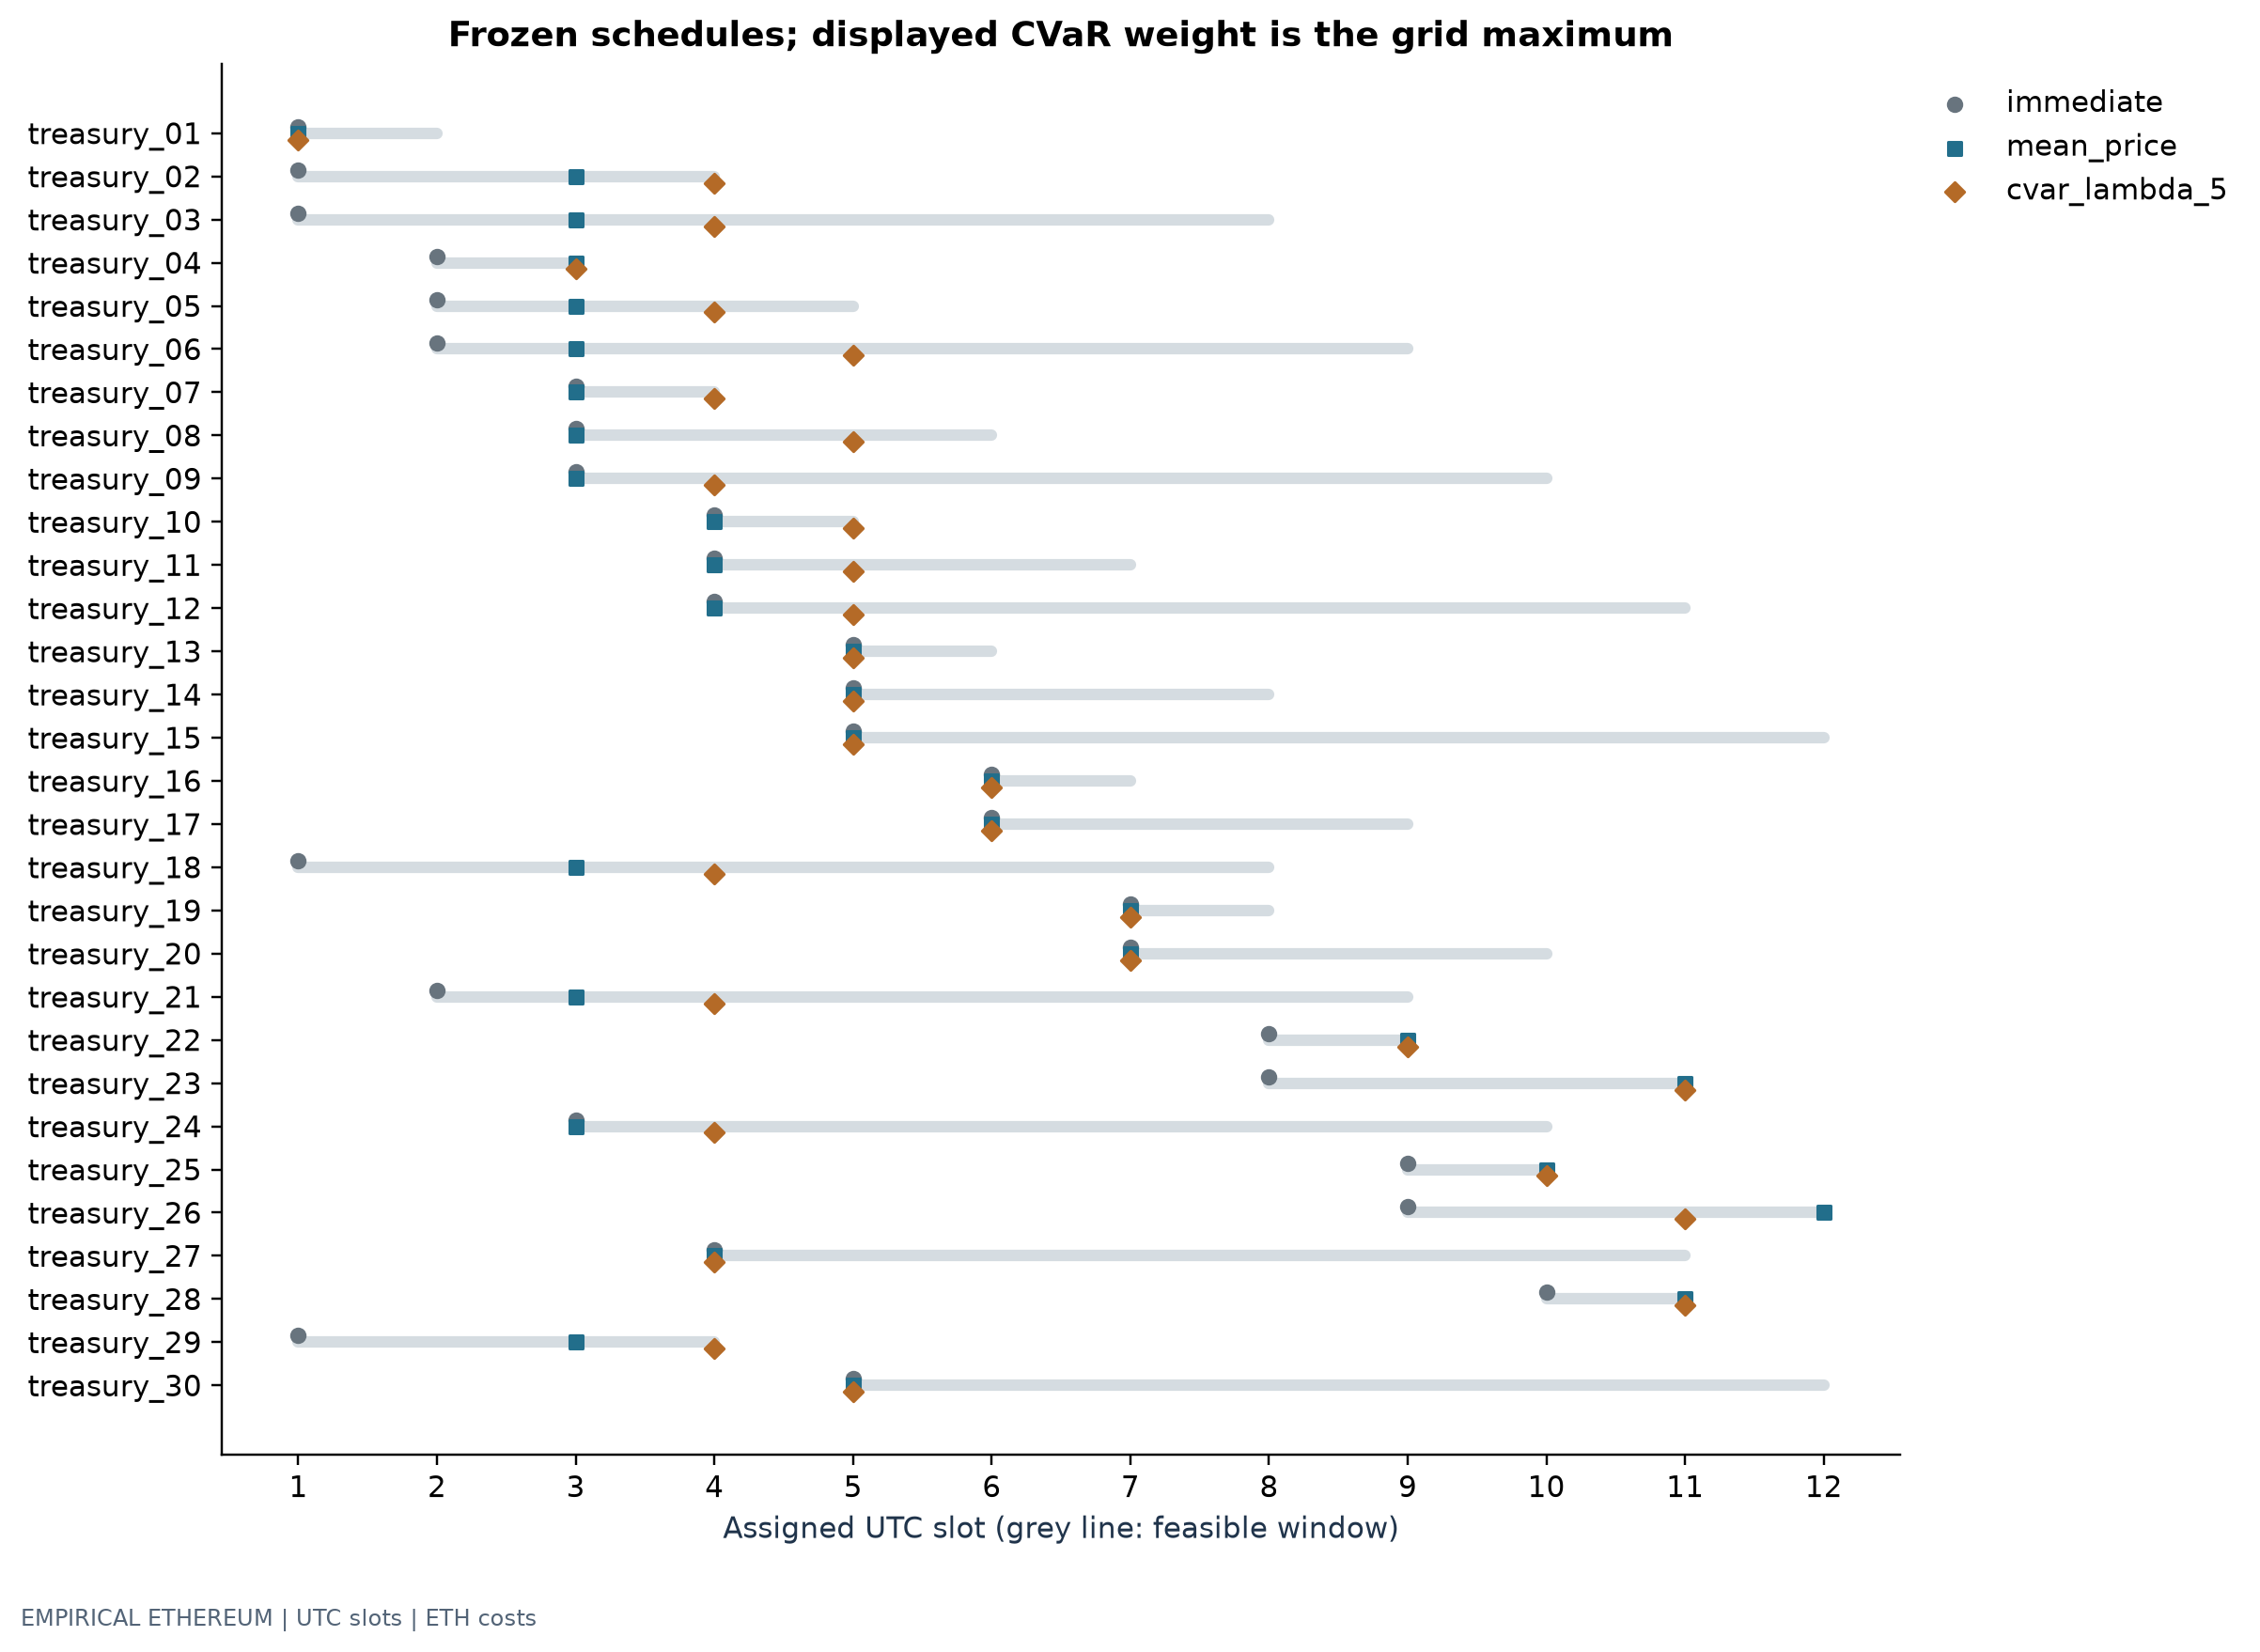

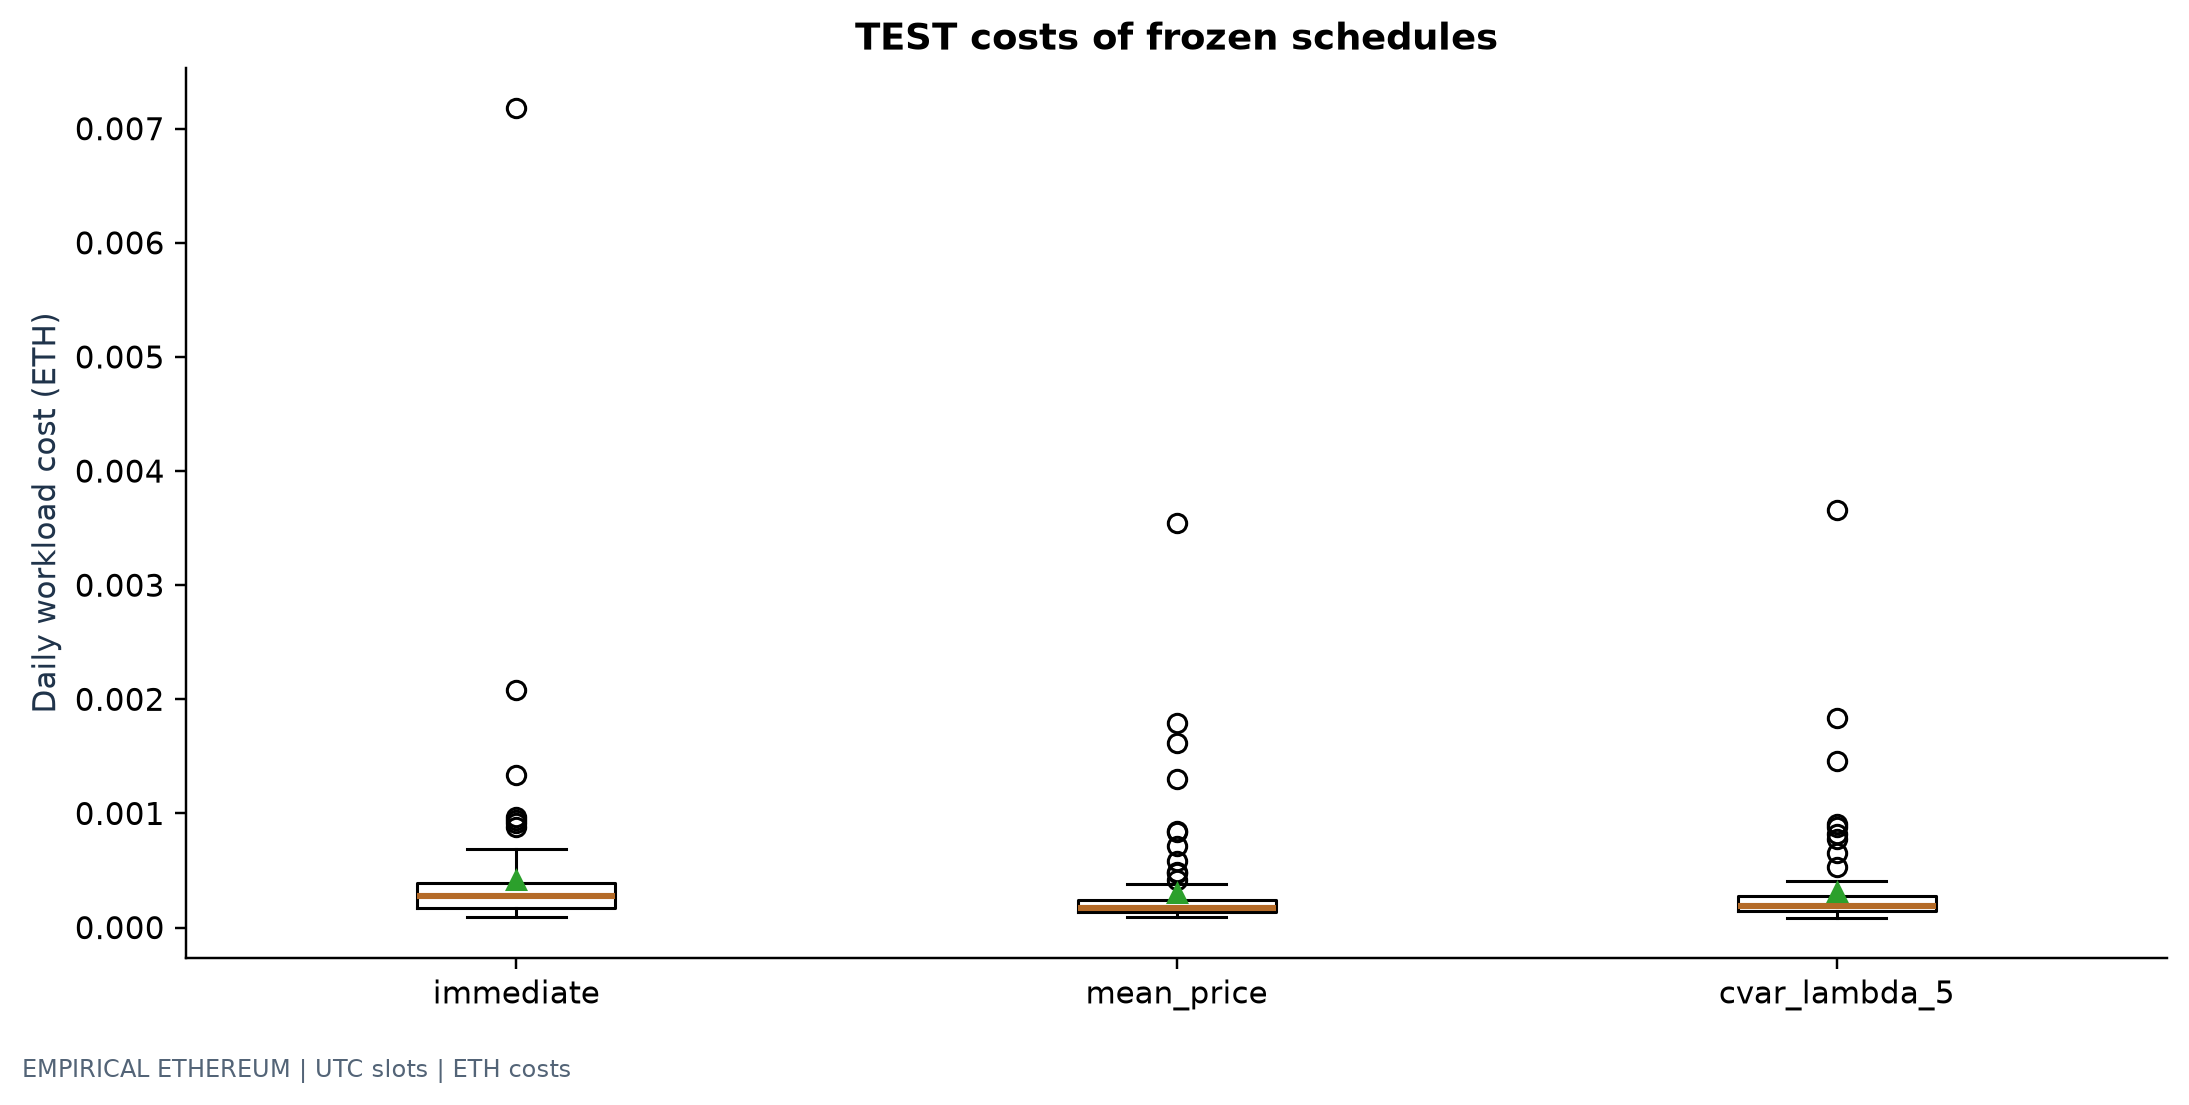

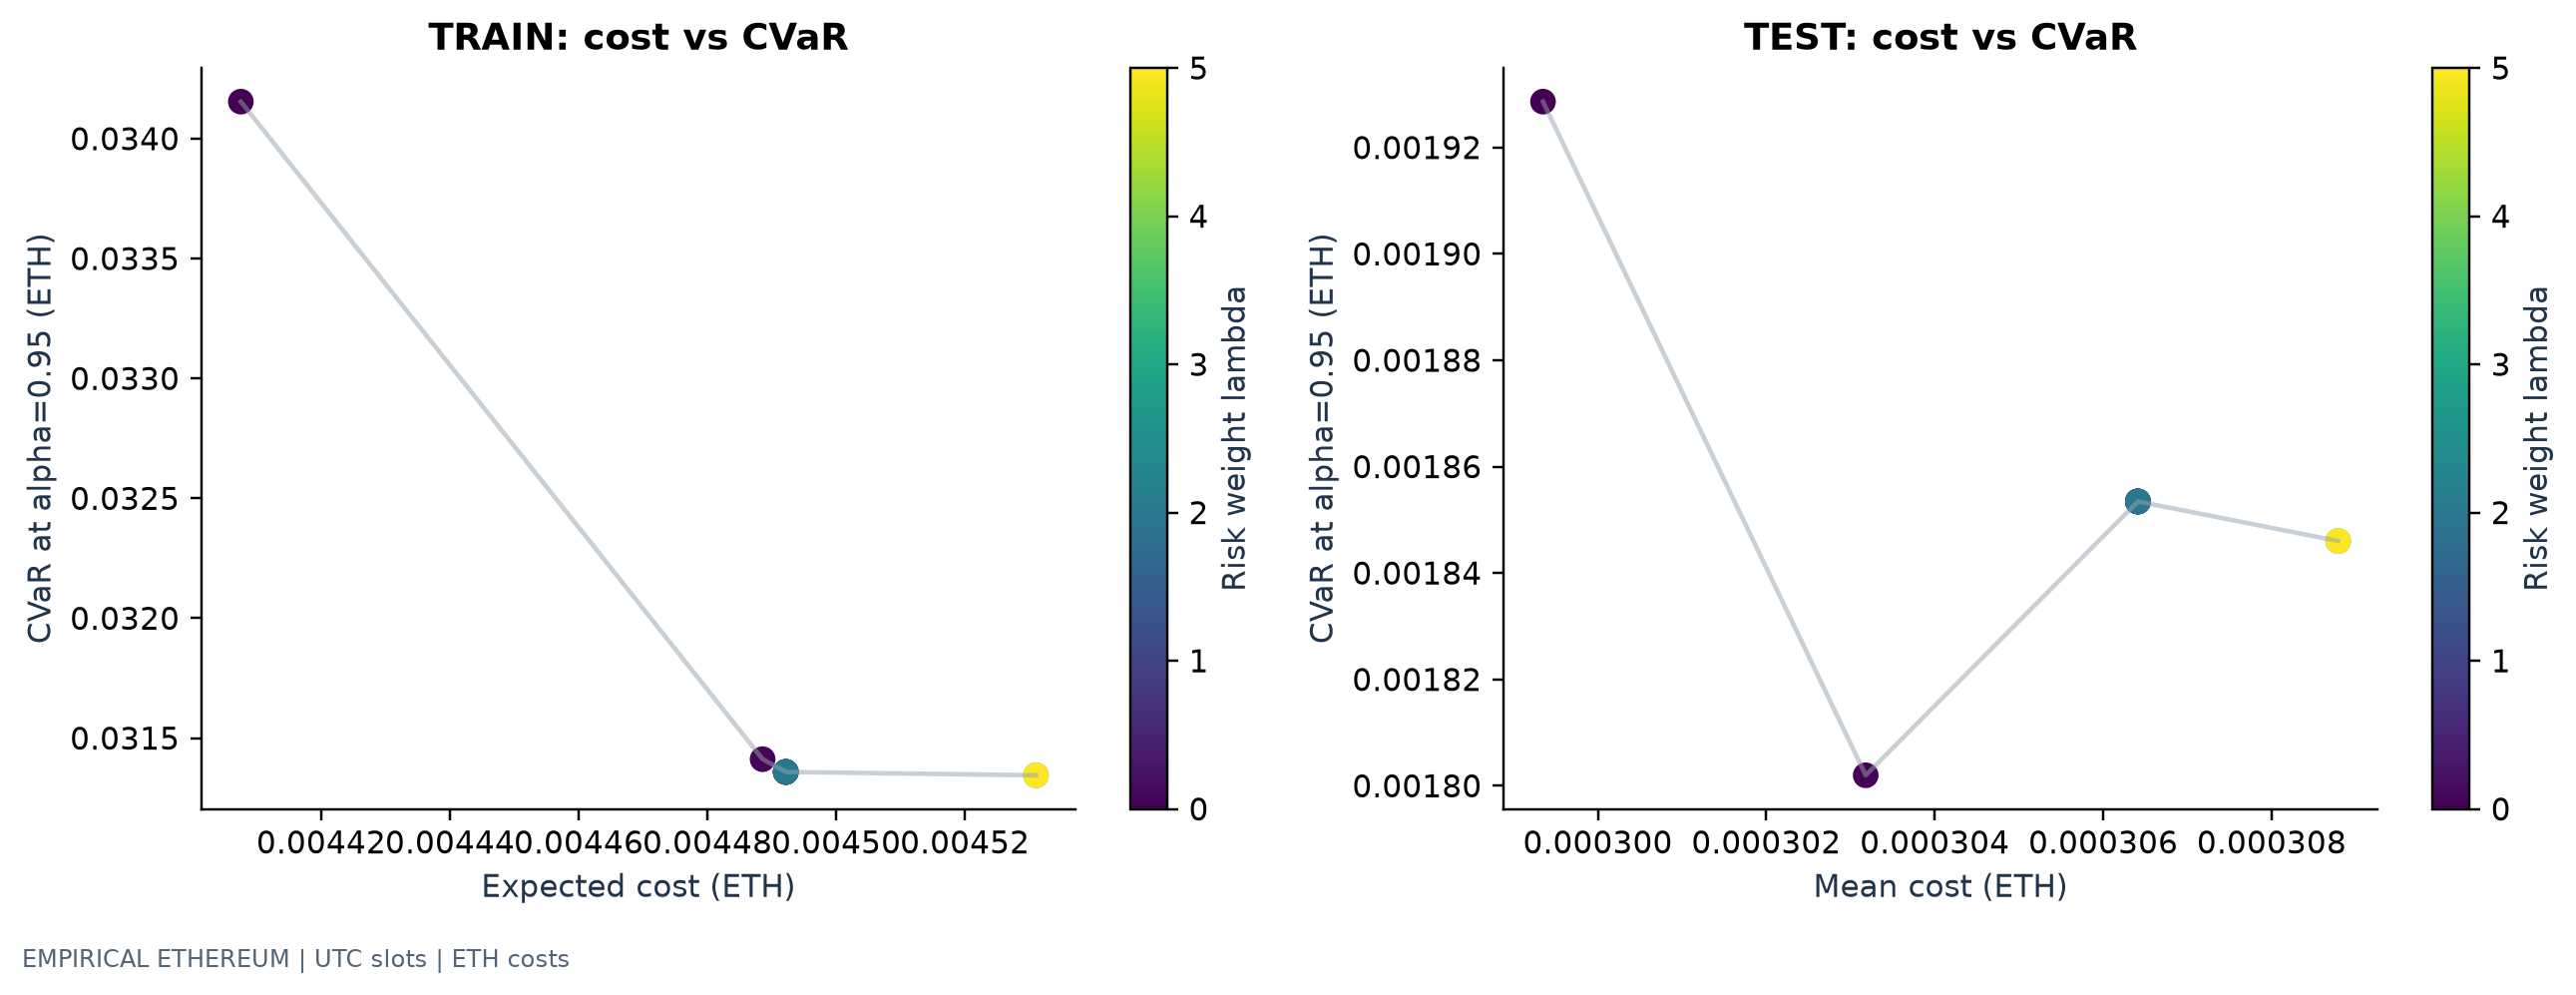

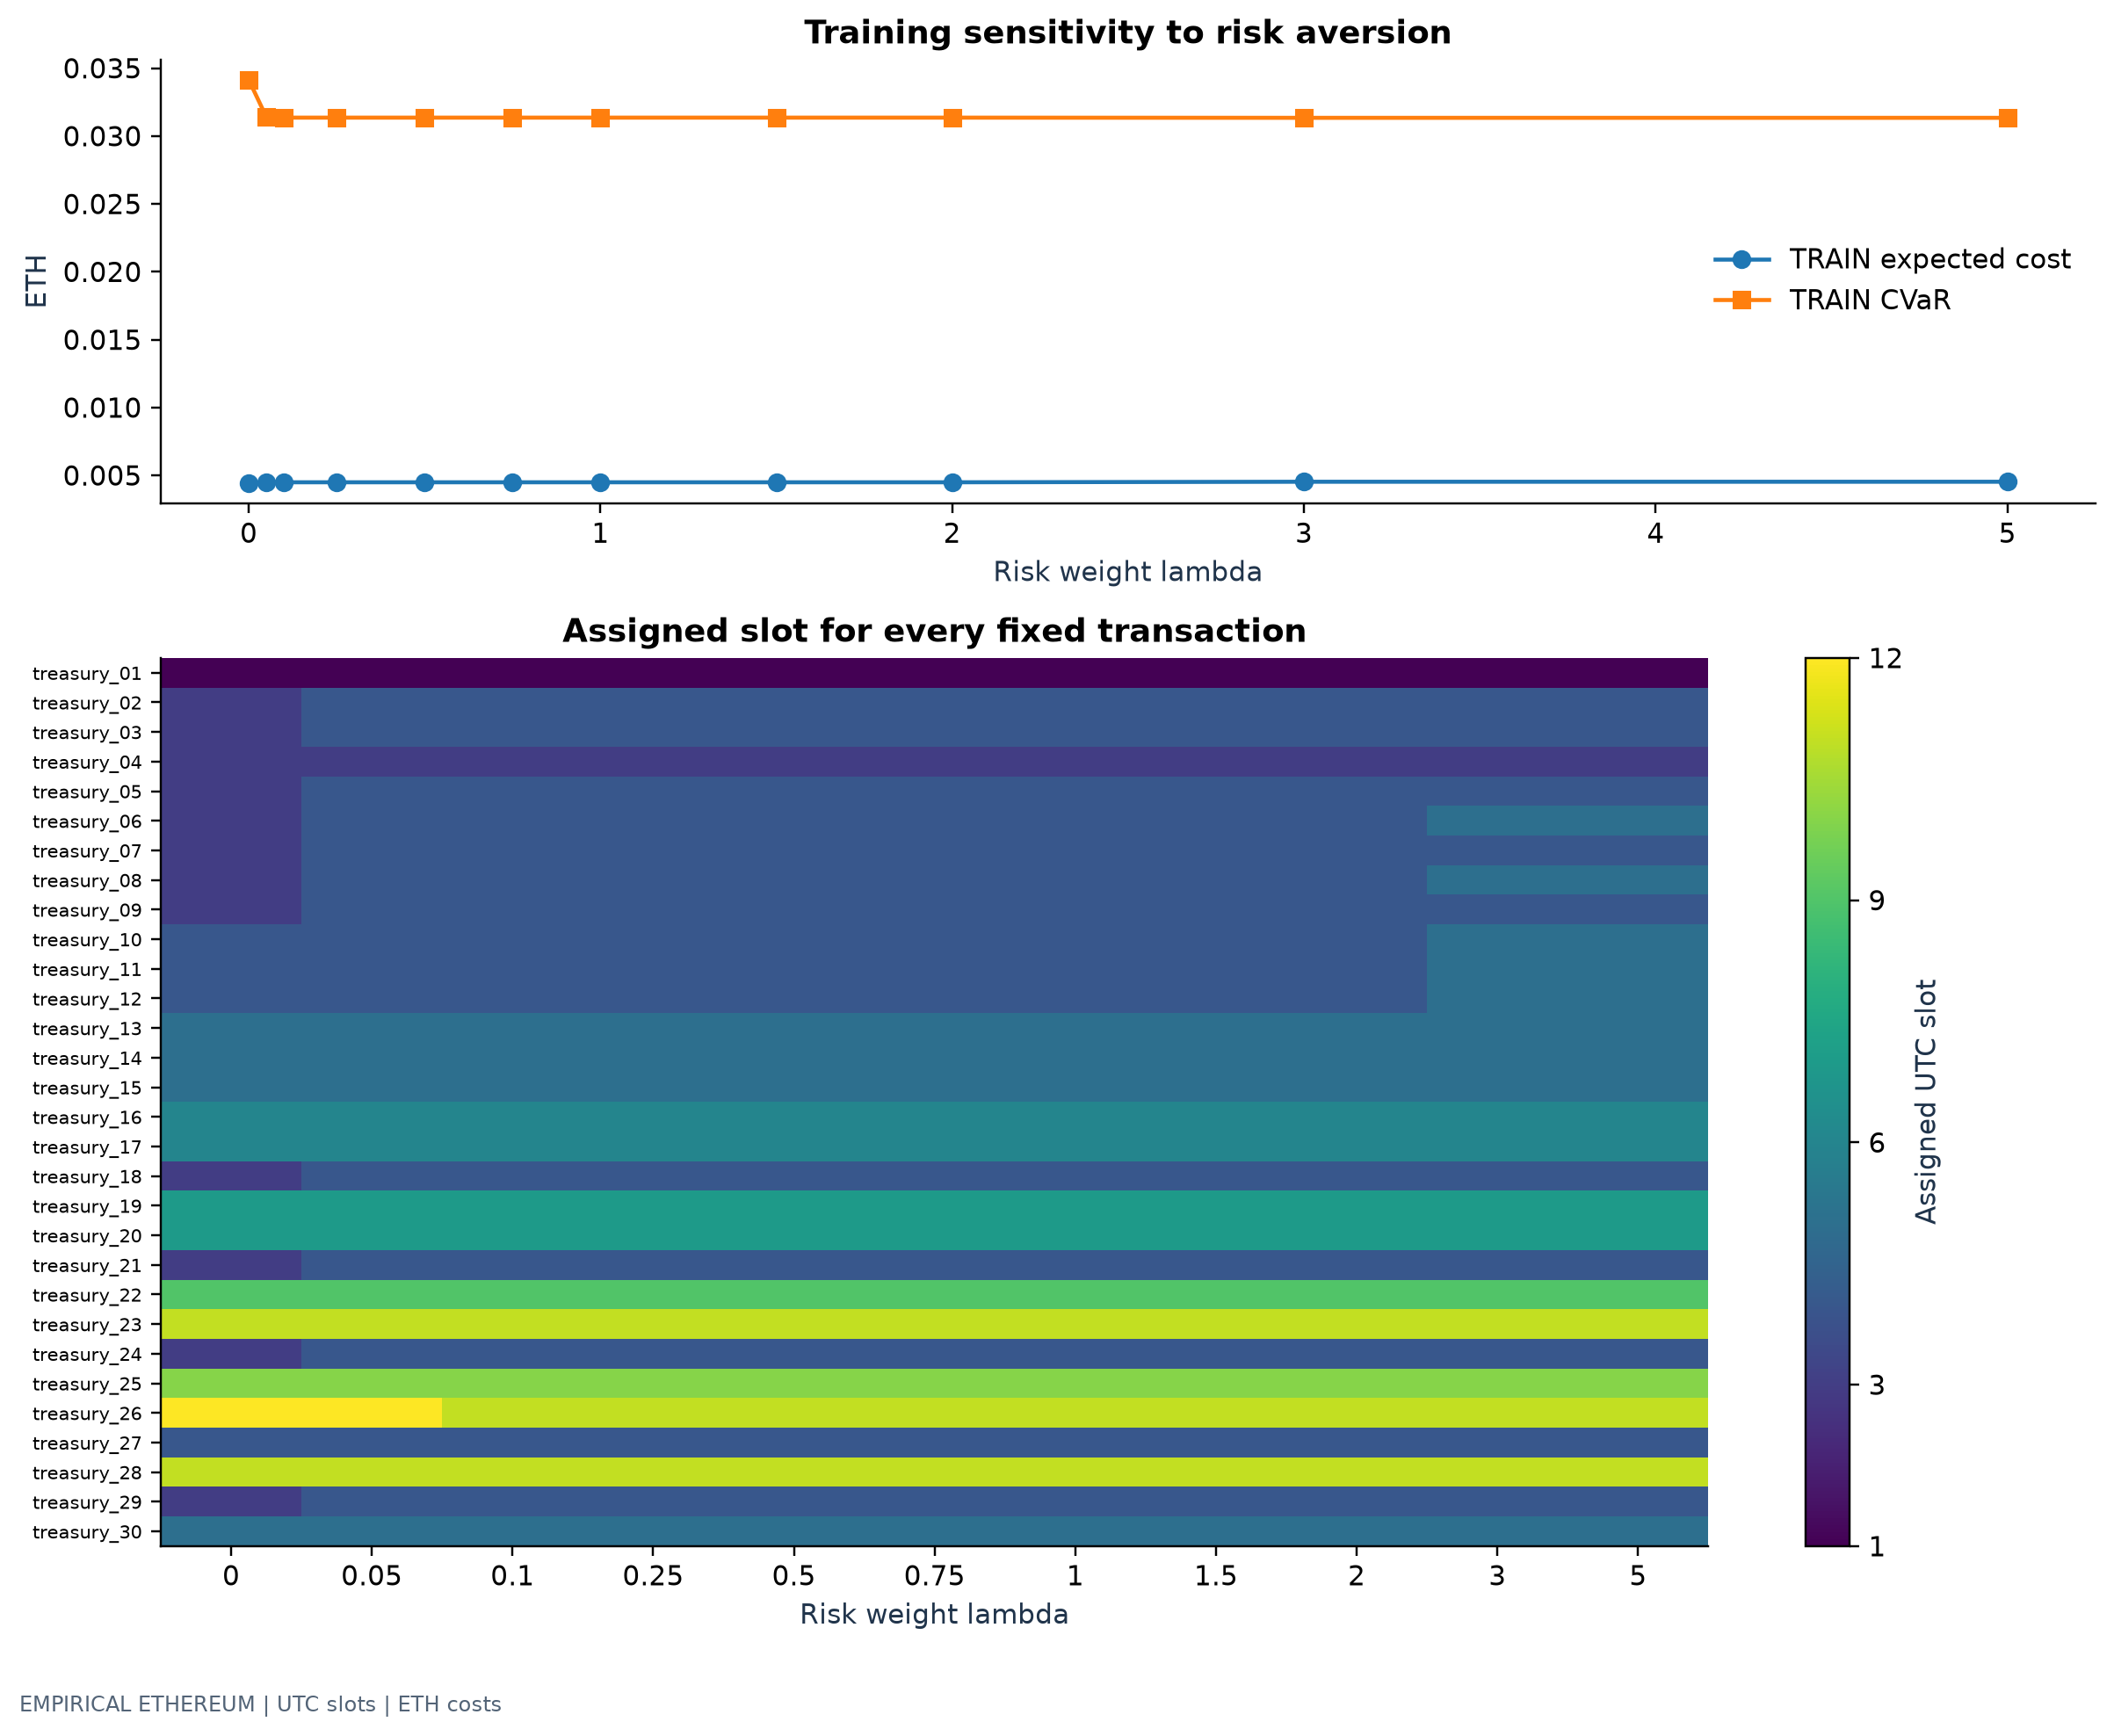

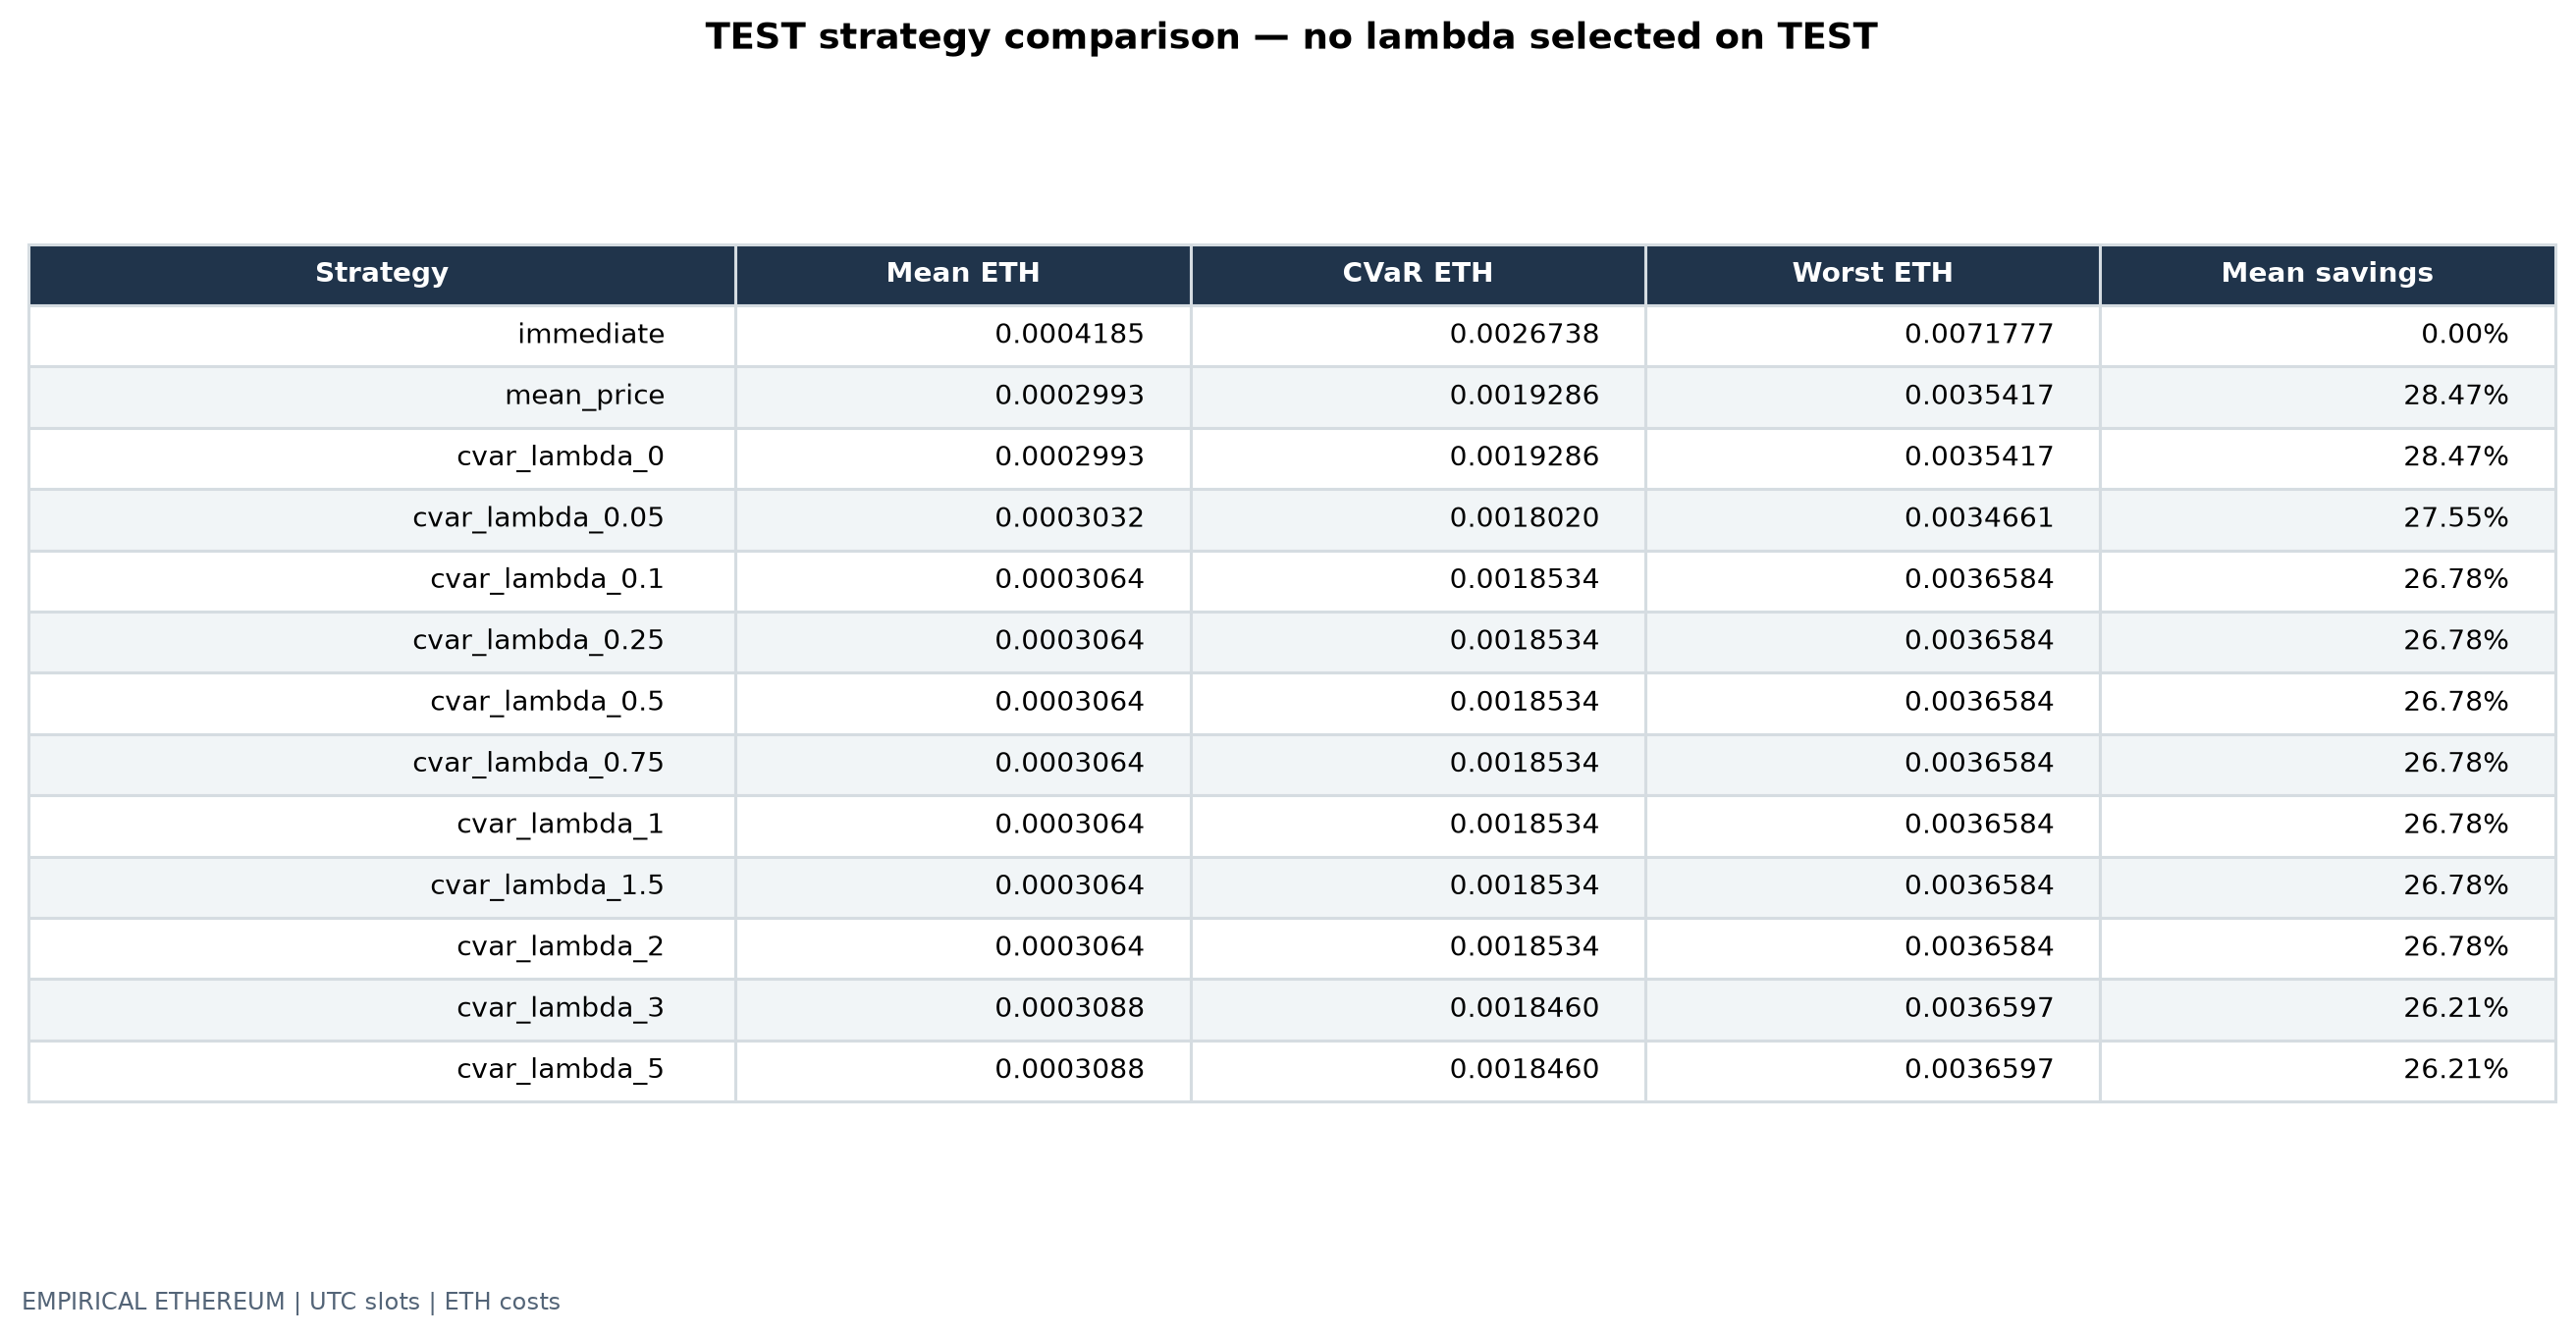

Saved 20 PNG/PDF figure files. The CLI also writes complete metadata/report artifacts.


In [10]:
if DATA_AVAILABLE:
    from gasopt.plots import save_study_plots
    schedule_rows = [{'strategy': name, 'transaction_id': tx.id, 'slot': schedule[tx.id]}
                     for name, schedule in fitted.schedules.items() for tx in transactions]
    study = {'fitted': fitted, 'transactions': transactions, 'workload': workload,
             'workload_construction': construction, 'train_slots': train_slots, 'test_slots': test_slots,
             'test_daily_costs': test_daily_costs, 'test_metrics': test_metrics,
             'schedules': pd.DataFrame(schedule_rows), 'train_count': len(train), 'test_count': len(test)}
    OUTPUT.mkdir(parents=True, exist_ok=True)
    fitted.training_metrics.to_csv(OUTPUT / 'train_metrics.csv', index=False)
    test_metrics.to_csv(OUTPUT / 'test_metrics.csv', index=False)
    test_daily_costs.to_csv(OUTPUT / 'test_daily_costs.csv')
    study['schedules'].to_csv(OUTPUT / 'schedules.csv', index=False)
    plot_paths = save_study_plots(slots, observations, study, config, OUTPUT / 'plots', label=DATA_LABEL)
    for name in ('04_schedule_comparison', '05_test_cost_distributions', '06_cost_risk_tradeoff',
                 '07_lambda_sensitivity', '08_strategy_comparison'):
        display(Image(filename=str(OUTPUT / 'plots' / f'{name}.png')))
    print(f'Saved {len(plot_paths)} PNG/PDF figure files. The CLI also writes complete metadata/report artifacts.')

## 18. Interpretation

Assess whether larger risk weights change assignments, increase TRAIN expected
cost, and reduce TRAIN CVaR. Report actual TEST outcomes even when savings are
negative or risk reduction does not generalize. TRAIN improvements establish
optimization behavior; TEST comparisons address this specific chronological
holdout only. Do not select the best-looking TEST lambda and call that an unbiased
strategy. Stable schedules across weights are a legitimate empirical result.

**Exercise:** use `test_daily_costs` to calculate mean daily percentage savings
and compare it with the reported ratio-of-means savings. Why can they differ?

In [11]:
if DATA_AVAILABLE:
    daily_fraction = (test_daily_costs.immediate - test_daily_costs.mean_price) / test_daily_costs.immediate
    principal = test_metrics.set_index('strategy').loc['mean_price', 'test_savings_fraction']
    display(pd.Series({'ratio_of_mean_costs': principal,
                       'mean_of_daily_savings_fractions': daily_fraction.mean()}, name='Different estimands').to_frame())
    # Ratio of means weights days by their immediate execution cost; the second gives each day equal weight.

,Different estimands
ratio_of_mean_costs,0.284666891
mean_of_daily_savings_fractions,0.219720575


## 19. Limitations

Slot medians are robust price proxies, not guaranteed execution prices. Their
CVaR does not capture every transaction-level fee spike within a two-hour slot.
The fixed workload approximates a hypothetical treasury and is not an observed
historical treasury order book. Timing classes are business assumptions.

Complete-day removal may bias the sample. Day-stratified gas-use selection is
not transaction-frequency sampling. Chronological splitting prevents direct
look-ahead but does not eliminate regime changes or serial dependence. A 90-day
TEST window has only 4.5 equivalents in a 5% tail; risk estimates can be unstable.

Gas use is fixed, and transactions are price-taking. Inclusion uncertainty,
nonce/dependency constraints, failed execution, dynamic adaptation, blob fees
and ETH/USD risk are omitted. No forecasts, ML, MEV, Layer 2, batching, custom
branch-and-bound or live monitoring are added. No React, FastAPI, Docker or
PowerPoint is created. Phase 2 requires actual local Dune extracts before any
empirical conclusion can be drawn.